### Training Data Analysis

In [2]:
import pandas as pd
import numpy as np
import os

file_list = [
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Industrials.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Technology.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Financial_Services.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Utilities.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Healthcare.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Unknown.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Energy.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Consumer_Defensive.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Real_Estate.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Basic_Materials.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Consumer_Cyclical.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Communication_Services.csv'
]

# ==================================================
# CONFIGURATION
# ==================================================

RISK_FREE_RATE = 0.02  # 2% annual risk-free rate
MIN_DAYS = 252  # Minimum 1 year of trading days (approx 252 days)
TRAINING_START = '2010-01-01'
TRAINING_END = '2016-12-31'

# ==================================================
# FUNCTION: CALCULATE SHARPE FOR A SINGLE STOCK
# ==================================================

def calculate_sharpe(returns_series, risk_free_rate=RISK_FREE_RATE, min_obs=MIN_DAYS):
    """
    Calculate Sharpe ratio for a single stock.
    Zeros are treated as missing data (non-trading days).
    
    Parameters:
    - returns_series: Pandas Series of daily returns
    - risk_free_rate: Annual risk-free rate
    - min_obs: Minimum number of valid observations required
    
    Returns:
    - Sharpe ratio (or NaN if insufficient data)
    """
    # Convert zeros to NaN (non-trading days)
    clean_series = returns_series.replace(0, np.nan)
    
    # Drop NaN values
    valid_returns = clean_series.dropna()
    
    # Check if we have enough data
    if len(valid_returns) < min_obs:
        return np.nan
    
    # Annualise
    annual_return = valid_returns.mean() * 252
    annual_vol = valid_returns.std() * np.sqrt(252)
    
    if annual_vol > 0 and not np.isnan(annual_vol):
        sharpe = (annual_return - risk_free_rate) / annual_vol
    else:
        sharpe = np.nan
    
    return sharpe


In [3]:
# ==================================================
# FUNCTION: LOAD AND CLEAN A SINGLE SECTOR CSV
# ==================================================

def load_sector_returns(file_path, start_date, end_date):
    """
    Load a sector CSV file and prepare returns data.
    
    Parameters:
    - file_path: Path to CSV file
    - start_date: Start of period
    - end_date: End of period
    
    Returns:
    - sector_returns: DataFrame of returns for the sector
    - sector_name: Name of the sector
    """
    sector_name = os.path.basename(file_path).replace('.csv', '')
    
    # Load CSV
    df = pd.read_csv(file_path)
    
    # Convert Date column to datetime
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    
    # Subset to training period
    df = df.loc[start_date:end_date]
    
    if df.empty:
        print(f"  WARNING: No data for {sector_name} in this period")
        return None, sector_name
    
    # Remove the first row if it's all zeros (e.g., 1995-01-02)
    if (df.iloc[0] == 0).all():
        df = df.iloc[1:]
    
    print(f"  {sector_name}: {df.shape[1]} stocks, {df.shape[0]} days")
    
    return df, sector_name


#### Avg_sharpe = Average sharpe ratio of EACH stock within each sector 

In [4]:
# ==================================================
# MAIN: CALCULATE SHARPE RATIOS FOR ALL SECTORS
# ==================================================

print("=" * 60)
print("CALCULATING SHARPE RATIOS BY SECTOR (2010-2016)")
print("=" * 60)

all_results = []  # List to store (sector, stock, sharpe)
sector_summaries = []  # List to store summary per sector

for file_path in file_list:
    # Load sector data
    sector_returns, sector_name = load_sector_returns(
        file_path, TRAINING_START, TRAINING_END
    )
    
    if sector_returns is None:
        continue
    
    print(f"\n  Processing {sector_name}...")
    
    # Calculate Sharpe ratio for each stock in this sector
    sector_results = []
    for stock in sector_returns.columns:
        sharpe = calculate_sharpe(sector_returns[stock])
        if not np.isnan(sharpe):
            sector_results.append({
                'Sector': sector_name,
                'Stock': stock,
                'Sharpe': sharpe
            })
            all_results.append({
                'Sector': sector_name,
                'Stock': stock,
                'Sharpe': sharpe
            })
    
    # Sort within sector
    sector_results_df = pd.DataFrame(sector_results).sort_values('Sharpe', ascending=False)
    
    # Summary for this sector
    sector_summaries.append({
        'Sector': sector_name,
        'Total_Stocks': len(sector_returns.columns),
        'Qualified_Stocks': len(sector_results),
        'Best_Stock': sector_results_df.iloc[0]['Stock'] if len(sector_results_df) > 0 else None,
        'Best_Sharpe': sector_results_df.iloc[0]['Sharpe'] if len(sector_results_df) > 0 else None,
        'Avg_Sharpe': sector_results_df['Sharpe'].mean() if len(sector_results_df) > 0 else None
    })
    
    print(f"    Qualified stocks: {len(sector_results)} / {len(sector_returns.columns)}")
    print(f"    Best Sharpe: {sector_results_df.iloc[0]['Sharpe']:.4f} ({sector_results_df.iloc[0]['Stock']})")


CALCULATING SHARPE RATIOS BY SECTOR (2010-2016)
  Industrials: 67 stocks, 1825 days

  Processing Industrials...
    Qualified stocks: 67 / 67
    Best Sharpe: 1.2435 (NOC US Equity)
  Technology: 51 stocks, 1825 days

  Processing Technology...
    Qualified stocks: 50 / 51
    Best Sharpe: 1.0561 (IT US Equity)
  Financial_Services: 59 stocks, 1825 days

  Processing Financial_Services...
    Qualified stocks: 58 / 59
    Best Sharpe: 1.0204 (CINF US Equity)
  Utilities: 28 stocks, 1825 days

  Processing Utilities...
    Qualified stocks: 28 / 28
    Best Sharpe: 1.1540 (NI US Equity)
  Healthcare: 51 stocks, 1825 days

  Processing Healthcare...
    Qualified stocks: 49 / 51
    Best Sharpe: 1.1114 (UNH US Equity)
  Unknown: 237 stocks, 1825 days

  Processing Unknown...
    Qualified stocks: 223 / 237
    Best Sharpe: 1.3985 (0961514D US Equity)
  Energy: 27 stocks, 1825 days

  Processing Energy...
    Qualified stocks: 27 / 27
    Best Sharpe: 1.4096 (EP US Equity)
  Consumer_De

In [5]:
# ==================================================
# CREATE MASTER DATAFRAMES
# ==================================================

# All qualified stocks across all sectors
all_results_df = pd.DataFrame(all_results).sort_values('Sharpe', ascending=False)

# Sector summary
sector_summary_df = pd.DataFrame(sector_summaries)

# ==================================================
# DISPLAY RESULTS
# ==================================================

print("\n" + "=" * 60)
print("TOP 20 STOCKS BY SHARPE RATIO (ALL SECTORS)")
print("=" * 60)
print(all_results_df.head(20).to_string(index=False))

print("\n" + "=" * 60)
print("SECTOR SUMMARY")
print("=" * 60)
print(sector_summary_df.to_string(index=False))

print("\n" + "=" * 60)
print("BEST STOCK PER SECTOR")
print("=" * 60)
best_per_sector = all_results_df.groupby('Sector').first().reset_index()
print(best_per_sector[['Sector', 'Stock', 'Sharpe']].to_string(index=False))


TOP 20 STOCKS BY SHARPE RATIO (ALL SECTORS)
            Sector              Stock   Sharpe
Consumer_Defensive       MO US Equity 1.418750
            Energy       EP US Equity 1.409623
           Unknown 0961514D US Equity 1.398497
           Unknown     GENZ US Equity 1.374545
           Unknown      RAI US Equity 1.342510
 Consumer_Cyclical     ORLY US Equity 1.299917
       Real_Estate      EXR US Equity 1.287389
 Consumer_Cyclical      AZO US Equity 1.259883
       Industrials      NOC US Equity 1.243472
           Unknown      HSH US Equity 1.209874
 Consumer_Cyclical       HD US Equity 1.200028
 Consumer_Cyclical     ROST US Equity 1.195322
       Industrials      LMT US Equity 1.162321
         Utilities       NI US Equity 1.153977
Consumer_Defensive      STZ US Equity 1.147142
           Unknown       GR US Equity 1.145247
       Industrials      ALK US Equity 1.139809
       Industrials     CTAS US Equity 1.129602
           Unknown    CMCSK US Equity 1.116294
        Healthc

In [6]:
# # ==================================================
# # SAVE RESULTS TO CSV
# # ==================================================

# all_results_df.to_csv('sharpe_ratios_all_stocks.csv', index=False)
# sector_summary_df.to_csv('sharpe_ratios_sector_summary.csv', index=False)

# print("\nSaved results to 'sharpe_ratios_all_stocks.csv'")
# print("Saved sector summary to 'sharpe_ratios_sector_summary.csv'")

# ==================================================
# SELECT TOP K STOCKS AFTER MISSING-DATA FILTER
# ==================================================

TOP_K = 50
MAX_EFFECTIVE_MISSING_PCT = 20

# Build sector_data here so the missing-data check uses the same
# training period used to calculate Sharpe ratios.
sector_data = {}
for file_path in file_list:
    sector_returns, sector_name = load_sector_returns(file_path, TRAINING_START, TRAINING_END)
    if sector_returns is not None:
        sector_data[sector_name] = sector_returns

missing_rows = []
for _, row in all_results_df.iterrows():
    stock = row['Stock']
    sector = row['Sector']

    if sector not in sector_data or stock not in sector_data[sector].columns:
        continue

    s = sector_data[sector][stock]
    missing_count = s.isna().sum()
    zero_count = (s == 0).sum()
    effective_missing_count = (s.isna() | (s == 0)).sum()
    total_count = len(s)

    missing_rows.append({
        'Stock': stock,
        'Sector': sector,
        'Missing_count': missing_count,
        'Missing_pct': missing_count / total_count * 100,
        'Zero_return_count': zero_count,
        'Zero_return_pct': zero_count / total_count * 100,
        'Effective_missing_count_NaN_or_zero': effective_missing_count,
        'Effective_missing_pct_NaN_or_zero': effective_missing_count / total_count * 100,
    })

missing_summary = pd.DataFrame(missing_rows)

valid_stocks = missing_summary.loc[
    missing_summary['Effective_missing_pct_NaN_or_zero'] <= MAX_EFFECTIVE_MISSING_PCT,
    'Stock'
]

all_results_df_filtered = all_results_df[
    all_results_df['Stock'].isin(valid_stocks)
].copy()

top_stocks = all_results_df_filtered.head(TOP_K)['Stock'].tolist()
top_stocks_with_sectors = all_results_df_filtered.head(TOP_K)[['Stock', 'Sector', 'Sharpe']]

print("\n" + "=" * 60)
print(f"TOP {len(top_stocks)} STOCKS SELECTED AFTER MISSING-DATA FILTER")
print("=" * 60)
print(f"Training period: {TRAINING_START} to {TRAINING_END}")
print(f"Maximum effective missing allowed: {MAX_EFFECTIVE_MISSING_PCT}%")
print(top_stocks_with_sectors.to_string(index=False))

print("\nMissing-data summary for selected stocks:")
selected_missing_summary = missing_summary[
    missing_summary['Stock'].isin(top_stocks)
].sort_values('Effective_missing_pct_NaN_or_zero', ascending=False)
print(selected_missing_summary.round(2).to_string(index=False))

print(f"\nSelected {len(top_stocks)} stocks for portfolio optimisation")


  Industrials: 67 stocks, 1825 days
  Technology: 51 stocks, 1825 days
  Financial_Services: 59 stocks, 1825 days
  Utilities: 28 stocks, 1825 days
  Healthcare: 51 stocks, 1825 days
  Unknown: 237 stocks, 1825 days
  Energy: 27 stocks, 1825 days
  Consumer_Defensive: 30 stocks, 1825 days
  Real_Estate: 30 stocks, 1825 days
  Basic_Materials: 20 stocks, 1825 days
  Consumer_Cyclical: 65 stocks, 1825 days
  Communication_Services: 15 stocks, 1825 days

TOP 50 STOCKS SELECTED AFTER MISSING-DATA FILTER
Training period: 2010-01-01 to 2016-12-31
Maximum effective missing allowed: 20%
          Stock                 Sector   Sharpe
   MO US Equity     Consumer_Defensive 1.418750
  RAI US Equity                Unknown 1.342510
 ORLY US Equity      Consumer_Cyclical 1.299917
  EXR US Equity            Real_Estate 1.287389
  AZO US Equity      Consumer_Cyclical 1.259883
  NOC US Equity            Industrials 1.243472
   HD US Equity      Consumer_Cyclical 1.200028
 ROST US Equity      Consumer_

### Correlation Analysis


SECTOR CORRELATION MATRIX (equal‑weight sector returns)
                        Industrials  Technology  Financial_Services  \
Industrials                    1.00        0.89                0.89   
Technology                     0.89        1.00                0.83   
Financial_Services             0.89        0.83                1.00   
Utilities                      0.57        0.52                0.52   
Healthcare                     0.83        0.82                0.79   
Unknown                        0.95        0.91                0.90   
Energy                         0.81        0.74                0.75   
Consumer_Defensive             0.75        0.72                0.70   
Real_Estate                    0.77        0.73                0.73   
Basic_Materials                0.90        0.82                0.82   
Consumer_Cyclical              0.92        0.87                0.85   
Communication_Services         0.86        0.85                0.82   

                   

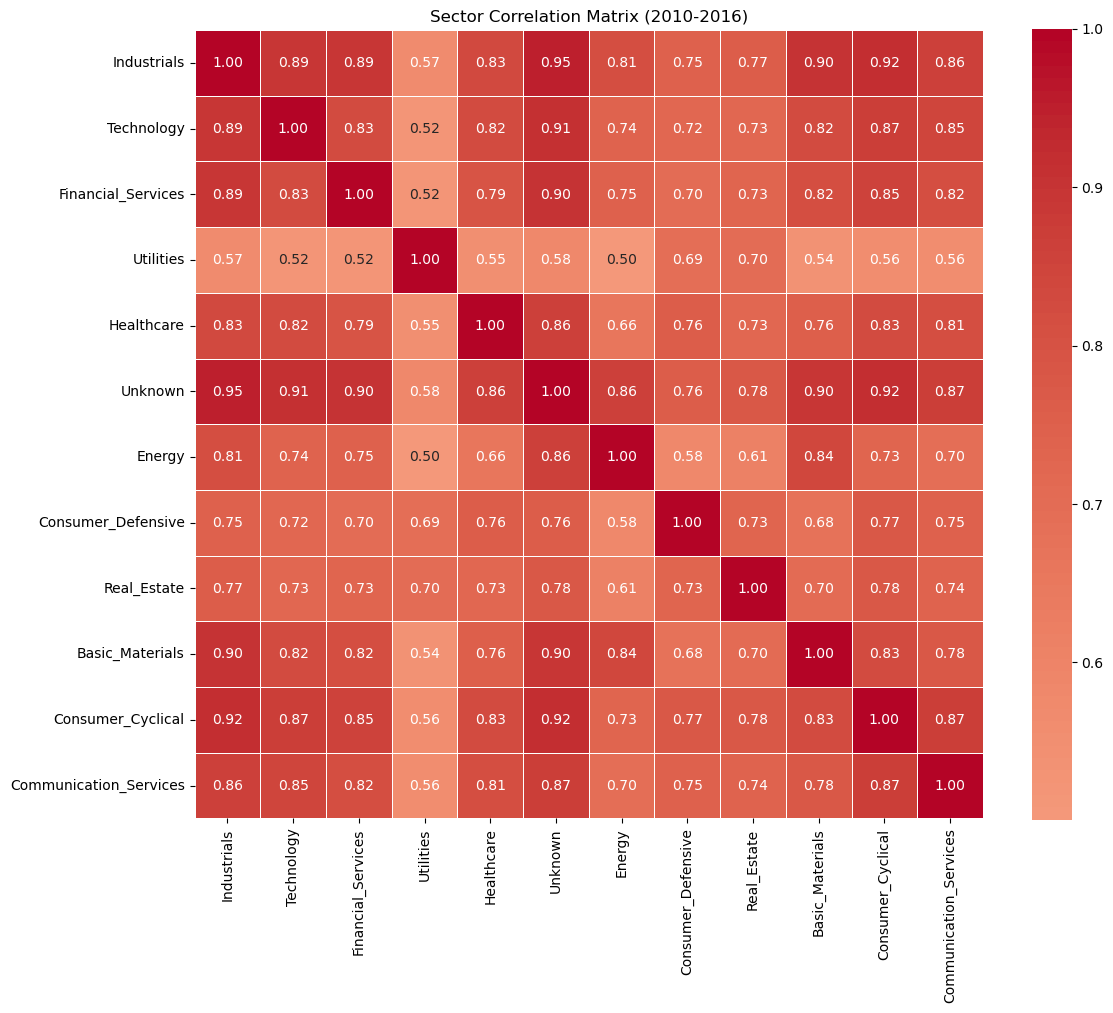

In [7]:
# --- 1. Reuse sector_data built during top-stock selection ---

# --- 2. Sector-level correlations (equal-weighted sector returns) ---
sector_avg_returns = {}
for sector, df in sector_data.items():
    # Convert zeros to NaN, then average across stocks in sector
    sector_clean = df.replace(0, np.nan)
    sector_avg = sector_clean.mean(axis=1, skipna=True)
    sector_avg_returns[sector] = sector_avg

sector_returns_df = pd.DataFrame(sector_avg_returns).dropna(how='all')
sector_corr = sector_returns_df.corr(min_periods=50)

print("\n" + "="*60)
print("SECTOR CORRELATION MATRIX (equal‑weight sector returns)")
print("="*60)
print(sector_corr.round(2))

# Optional: heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(sector_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Sector Correlation Matrix (2010-2016)')
plt.tight_layout()
plt.show()


In [8]:
# --- 3. Within-sector vs between-sector correlations for top 50 stocks ---
# Build a mapping from stock to its sector
top_stocks_list = top_stocks  # from your TOP_K selection
stock_to_sector = dict(zip(top_stocks_with_sectors['Stock'], 
                           top_stocks_with_sectors['Sector']))

# Collect cleaned returns (zeros → NaN) for the top 50 stocks
top_returns = []
for stock in top_stocks_list:
    # Find which sector this stock belongs to
    sector = stock_to_sector[stock]
    # Get the raw series from the sector DataFrame
    if stock in sector_data[sector].columns:
        series = sector_data[sector][stock].copy()
        series = series.replace(0, np.nan)   # treat zeros as missing
        top_returns.append(series)

if top_returns:
    returns_top = pd.concat(top_returns, axis=1)
    returns_top.columns = top_stocks_list
    corr_top = returns_top.corr(min_periods=50)

    # Compute average correlations
    within_corrs = []
    between_corrs = []
    n = len(top_stocks_list)
    for i in range(n):
        for j in range(i+1, n):
            stock_i = top_stocks_list[i]
            stock_j = top_stocks_list[j]
            sector_i = stock_to_sector[stock_i]
            sector_j = stock_to_sector[stock_j]
            corr_val = corr_top.iloc[i, j]
            if not np.isnan(corr_val):
                if sector_i == sector_j:
                    within_corrs.append(corr_val)
                else:
                    between_corrs.append(corr_val)

    print("\n" + "="*60)
    print("DIVERSIFICATION CHECK (Top 50 Stocks)")
    print("="*60)
    print(f"Average correlation WITHIN same sector: {np.mean(within_corrs):.4f}")
    print(f"Average correlation BETWEEN different sectors: {np.mean(between_corrs):.4f}")

    if np.mean(between_corrs) > 0.5:
        print("⚠️  High between‑sector correlation → portfolio may lack cross‑sector diversification.")
    elif np.mean(between_corrs) < 0.2:
        print("✓ Low between‑sector correlation → good diversification potential.")
    else:
        print("→ Moderate between‑sector correlation, reasonable diversification.")
else:
    print("Could not retrieve returns for top stocks.")


DIVERSIFICATION CHECK (Top 50 Stocks)
Average correlation WITHIN same sector: 0.4231
Average correlation BETWEEN different sectors: 0.3711
→ Moderate between‑sector correlation, reasonable diversification.


### Efficient frontier construction 

Forward selection on top 50 stocks (ordered by individual Sharpe):
k =  1 : Sharpe = 1.4188
k =  2 : Sharpe = 1.4863
k =  3 : Sharpe = 1.7408
k =  4 : Sharpe = 1.8221
k =  5 : Sharpe = 1.8601
k =  6 : Sharpe = 1.8758
k =  7 : Sharpe = 1.8876
k =  8 : Sharpe = 1.9046
k =  9 : Sharpe = 1.9153
k = 10 : Sharpe = 1.9482
k = 11 : Sharpe = 1.9802
k = 12 : Sharpe = 1.9782
k = 13 : Sharpe = 1.9990
k = 14 : Sharpe = 2.1606
k = 15 : Sharpe = 2.1607
k = 16 : Sharpe = 2.1462
k = 17 : Sharpe = 2.1059
k = 18 : Sharpe = 2.1306
k = 19 : Sharpe = 2.1355
k = 20 : Sharpe = 2.1537
k = 21 : Sharpe = 2.1769
k = 22 : Sharpe = 2.3189
k = 23 : Sharpe = 2.3377
k = 24 : Sharpe = 2.3107
k = 25 : Sharpe = 2.2977
k = 26 : Sharpe = 2.2886
k = 27 : Sharpe = 2.2867
k = 28 : Sharpe = 2.2914
k = 29 : Sharpe = 2.2860
k = 30 : Sharpe = 2.3105
k = 31 : Sharpe = 2.2802
k = 32 : Sharpe = 2.2626
k = 33 : Sharpe = 2.2550
k = 34 : Sharpe = 2.2561
k = 35 : Sharpe = 2.3462
k = 36 : Sharpe = 2.3311
k = 37 : Sharpe = 2.3390
k = 38 :

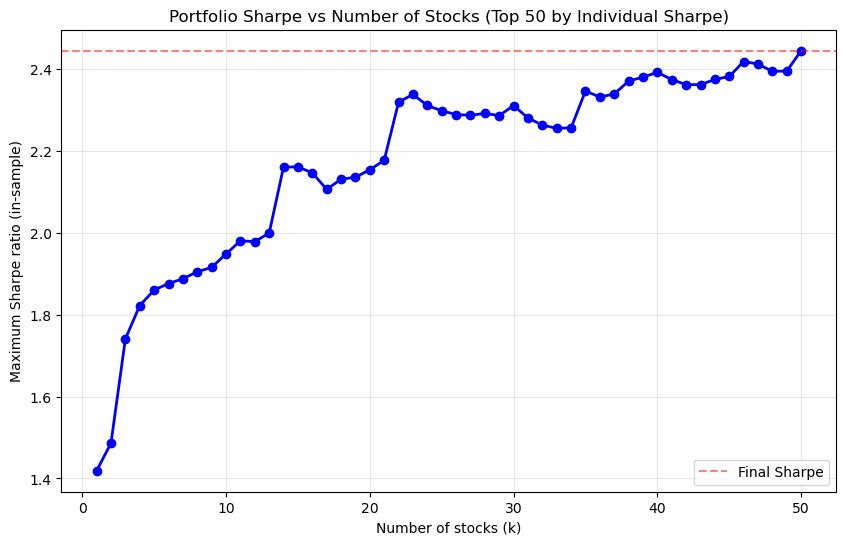


Highest Sharpe: 2.4444
Suggested optimal portfolio size: k = 22
Sharpe at k = 22: 2.3189
This is within 10% of the highest Sharpe.
Final Sharpe with all 50 stocks: 2.4444


In [15]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize

# --------------------------------------------------
# 1. Prepare cleaned returns for top 50 stocks
# --------------------------------------------------
# Assume you have a DataFrame `returns_top` (dates × top 50 stocks)
# with zeros already converted to NaN, and no NaN rows.

# If not already, create it:
# returns_top = ... (from earlier code, with zeros replaced by NaN)

# For safety, drop any rows that are all NaN
returns_clean = returns_top.dropna(how='all')

# --------------------------------------------------
# 2. Function to compute max Sharpe for a given set
# --------------------------------------------------
def max_sharpe(returns_df, risk_free=0.02):
    """Compute the maximum Sharpe ratio for a given set of stocks."""
    if returns_df.shape[1] == 0:
        return -np.inf
    if returns_df.shape[1] == 1:
        ret = returns_df.mean().iloc[0] * 252
        vol = returns_df.std().iloc[0] * np.sqrt(252)
        return (ret - risk_free)/vol if vol > 0 else -np.inf
    
    # Optimise weights
    mean_ret = returns_df.mean() * 252
    cov = returns_df.cov() * 252
    n = returns_df.shape[1]
    
    def neg_sharpe(w):
        port_ret = np.sum(w * mean_ret)
        port_vol = np.sqrt(w.T @ cov @ w)
        return -(port_ret - risk_free) / port_vol
    
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = tuple((0, 1) for _ in range(n))
    init = np.array([1/n] * n)
    result = minimize(neg_sharpe, init, method='SLSQP', bounds=bounds, constraints=constraints)
    if result.success:
        w_opt = result.x
        port_ret = np.sum(w_opt * mean_ret)
        port_vol = np.sqrt(w_opt.T @ cov @ w_opt)
        return (port_ret - risk_free) / port_vol
    else:
        return -np.inf

# --------------------------------------------------
# 3. Forward selection on top 50 (already sorted by Sharpe)
# --------------------------------------------------
# Use the top 50 stocks in the order they are ranked by individual Sharpe.
# We will add them one by one and compute the portfolio's max Sharpe.

ordered_stocks = top_stocks_with_sectors['Stock'].tolist()  # already sorted by Sharpe
portfolio_sharpe = []
current_returns = pd.DataFrame()

print("Forward selection on top 50 stocks (ordered by individual Sharpe):")
for i, stock in enumerate(ordered_stocks, 1):
    # Add this stock to the current portfolio
    if current_returns.empty:
        current_returns = returns_clean[[stock]].copy()
    else:
        current_returns = pd.concat([current_returns, returns_clean[[stock]]], axis=1)
    
    # Compute max Sharpe for the current portfolio
    sharpe = max_sharpe(current_returns.dropna())
    portfolio_sharpe.append(sharpe)
    print(f"k = {i:2d} : Sharpe = {sharpe:.4f}")

# --------------------------------------------------
# 4. Plot the results
# --------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(range(1, len(portfolio_sharpe)+1), portfolio_sharpe, 'bo-', linewidth=2, markersize=6)
plt.xlabel('Number of stocks (k)')
plt.ylabel('Maximum Sharpe ratio (in-sample)')
plt.title('Portfolio Sharpe vs Number of Stocks (Top 50 by Individual Sharpe)')
plt.grid(True, alpha=0.3)
plt.axhline(y=portfolio_sharpe[-1], color='r', linestyle='--', alpha=0.5, label='Final Sharpe')
plt.legend()
plt.show()

# --------------------------------------------------
# 5. Suggest optimal k (elbow detection)
# --------------------------------------------------
# Find the smallest k that is within 10% of the highest Sharpe
best_sharpe = max(portfolio_sharpe)
threshold = 0.90 * best_sharpe

optimal_k = 1
for k, sharpe in enumerate(portfolio_sharpe, 1):
    if sharpe >= threshold:
        optimal_k = k
        break

print(f"\nHighest Sharpe: {best_sharpe:.4f}")
print(f"Suggested optimal portfolio size: k = {optimal_k}")
print(f"Sharpe at k = {optimal_k}: {portfolio_sharpe[optimal_k-1]:.4f}")
print(f"This is within 10% of the highest Sharpe.")
print(f"Final Sharpe with all 50 stocks: {portfolio_sharpe[-1]:.4f}")

#### Testing the size of the portfolio on Training and Testing 

Loaded 12 sectors for testing period 2017-01-01 to 2019-12-31.
k =  1 : Out-of-sample Sharpe = -0.4383
k =  2 : Out-of-sample Sharpe = 2.8325
k =  3 : Out-of-sample Sharpe = 2.8501
k =  4 : Out-of-sample Sharpe = 2.8914
k =  5 : Out-of-sample Sharpe = 2.8941
k =  6 : Out-of-sample Sharpe = 2.9497
k =  7 : Out-of-sample Sharpe = 2.9780
k =  8 : Out-of-sample Sharpe = 2.9967
k =  9 : Out-of-sample Sharpe = 2.9968
k = 10 : Out-of-sample Sharpe = 2.9968
k = 11 : Out-of-sample Sharpe = 2.9968
k = 12 : Out-of-sample Sharpe = 2.9968
k = 13 : Out-of-sample Sharpe = 3.0326
k = 14 : Out-of-sample Sharpe = 3.0326
k = 15 : Out-of-sample Sharpe = 3.0477
k = 16 : Out-of-sample Sharpe = 3.0477
k = 17 : Out-of-sample Sharpe = 3.1169
k = 18 : Out-of-sample Sharpe = 3.1169
k = 19 : Out-of-sample Sharpe = 3.1169
k = 20 : Out-of-sample Sharpe = 3.1169
k = 21 : Out-of-sample Sharpe = 3.1169
k = 22 : Out-of-sample Sharpe = 3.1169
k = 23 : Out-of-sample Sharpe = 3.1976
k = 24 : Out-of-sample Sharpe = 3.1976


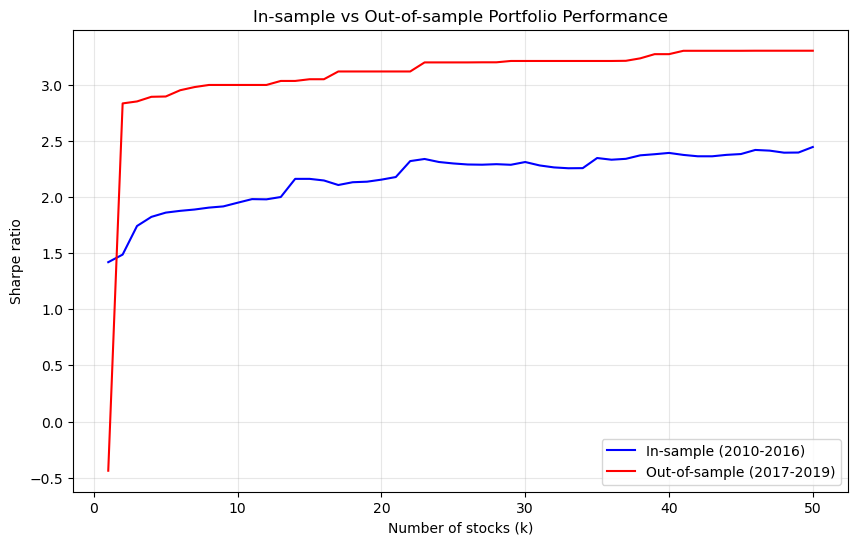


Best out-of-sample Sharpe: 3.3016 at k = 49
Smallest k within 5% of best: k = 23 (Sharpe = 3.1976)


In [10]:
import pandas as pd
import numpy as np
import os
from scipy.optimize import minimize

# --------------------------------------------------
# TEST FILE LIST (Sectors_test folder)
# --------------------------------------------------
test_file_list = [
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Industrials.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Technology.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Financial_Services.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Utilities.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Healthcare.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Unknown.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Energy.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Consumer_Defensive.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Real_Estate.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Basic_Materials.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Consumer_Cyclical.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Communication_Services.csv'
]

# --------------------------------------------------
# Configuration for testing period
# --------------------------------------------------
TESTING_START = '2017-01-01'
TESTING_END = '2019-12-31'

# --------------------------------------------------
# Function to load a sector CSV for the testing period
# --------------------------------------------------
def load_test_sector_returns(file_path, start_date, end_date):
    sector_name = os.path.basename(file_path).replace('.csv', '')
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df = df.loc[start_date:end_date]
    if df.empty:
        print(f"  WARNING: No test data for {sector_name}")
        return None, sector_name
    if (df.iloc[0] == 0).all():
        df = df.iloc[1:]
    return df, sector_name

# --------------------------------------------------
# Load all test sector data into a dictionary
# --------------------------------------------------
test_sector_data = {}
for file_path in test_file_list:
    sector_returns, sector_name = load_test_sector_returns(file_path, TESTING_START, TESTING_END)
    if sector_returns is not None:
        test_sector_data[sector_name] = sector_returns

print(f"Loaded {len(test_sector_data)} sectors for testing period {TESTING_START} to {TESTING_END}.")

# --------------------------------------------------
# Function to get cleaned returns for a list of stocks in the test period
# --------------------------------------------------
def get_test_returns(stock_list):
    all_data = []

    for sector, df in test_sector_data.items():
        common = [s for s in stock_list if s in df.columns]
        if common:
            sector_subset = df[common].replace(0, np.nan)
            all_data.append(sector_subset)

    if not all_data:
        return pd.DataFrame()

    combined = pd.concat(all_data, axis=1)

    # Keep columns in the exact same order as stock_list
    combined = combined.reindex(columns=[s for s in stock_list if s in combined.columns])

    # Drop only rows where every stock is missing
    combined = combined.dropna(how='all')

    return combined

# --------------------------------------------------
# Function to compute maximum Sharpe for a set of stocks
# --------------------------------------------------
def max_sharpe_test(returns_df, risk_free=0.02, min_obs=60):
    if returns_df.empty:
        return np.nan

    # Remove stocks with too little test data
    valid_cols = returns_df.columns[returns_df.notna().sum() >= min_obs]
    returns_df = returns_df[valid_cols]

    if returns_df.shape[1] == 0:
        return np.nan

    if returns_df.shape[1] == 1:
        s = returns_df.iloc[:, 0].dropna()
        if len(s) < min_obs:
            return np.nan

        ret = s.mean() * 252
        vol = s.std() * np.sqrt(252)
        return (ret - risk_free) / vol if vol > 0 else np.nan

    # Use pairwise covariance instead of dropping every row with any NaN
    mean_ret = returns_df.mean(skipna=True) * 252
    cov = returns_df.cov(min_periods=min_obs) * 252

    # Remove columns that still have invalid covariance values
    valid_cov_cols = cov.columns[~cov.isna().any()]
    mean_ret = mean_ret.loc[valid_cov_cols]
    cov = cov.loc[valid_cov_cols, valid_cov_cols]

    if len(mean_ret) == 0:
        return np.nan

    n = len(mean_ret)

    def neg_sharpe(w):
        port_ret = np.sum(w * mean_ret)
        port_vol = np.sqrt(w.T @ cov.values @ w)
        return -(port_ret - risk_free) / port_vol if port_vol > 0 else np.inf

    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = tuple((0, 1) for _ in range(n))
    init = np.array([1/n] * n)

    result = minimize(
        neg_sharpe,
        init,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        w_opt = result.x
        port_ret = np.sum(w_opt * mean_ret)
        port_vol = np.sqrt(w_opt.T @ cov.values @ w_opt)
        return (port_ret - risk_free) / port_vol if port_vol > 0 else np.nan

    return np.nan

# --------------------------------------------------
# Compute out-of-sample Sharpe for k = 1 to number of selected stocks
# --------------------------------------------------
ordered_stocks = top_stocks_with_sectors['Stock'].tolist()
oos_sharpe = []

for k in range(1, len(ordered_stocks) + 1):
    stocks_k = ordered_stocks[:k]
    test_returns = get_test_returns(stocks_k)
    sharpe = max_sharpe_test(test_returns) if not test_returns.empty else np.nan
    oos_sharpe.append(sharpe)
    print(f"k = {k:2d} : Out-of-sample Sharpe = {sharpe:.4f}")

# --------------------------------------------------
# Compare with in-sample Sharpe
# --------------------------------------------------
in_sample_sharpe = portfolio_sharpe[:len(oos_sharpe)]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(range(1, len(in_sample_sharpe) + 1), in_sample_sharpe, 'b-', label='In-sample (2010-2016)')
plt.plot(range(1, len(oos_sharpe) + 1), oos_sharpe, 'r-', label='Out-of-sample (2017-2019)')
plt.xlabel('Number of stocks (k)')
plt.ylabel('Sharpe ratio')
plt.title('In-sample vs Out-of-sample Portfolio Performance')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --------------------------------------------------
# Find best k based on out-of-sample Sharpe
# --------------------------------------------------
valid_oos = np.array(oos_sharpe, dtype=float)
if np.all(np.isnan(valid_oos)):
    best_k = min(10, len(ordered_stocks))
    print("No valid out-of-sample Sharpe values found; using fallback k.")
else:
    best_k = int(np.nanargmax(valid_oos)) + 1
    best_oos_sharpe = valid_oos[best_k - 1]
    print(f"\nBest out-of-sample Sharpe: {best_oos_sharpe:.4f} at k = {best_k}")

    threshold = 0.95 * best_oos_sharpe
    for k, sharpe in enumerate(valid_oos, 1):
        if not np.isnan(sharpe) and sharpe >= threshold:
            print(f"Smallest k within 5% of best: k = {k} (Sharpe = {sharpe:.4f})")
            break


##### The out-of-sample Sharpe ratio generally increased as more stocks were added, indicating that diversification improved portfolio performance during the 2017-2019 testing period. However, the improvement became marginal after approximately 23 stocks. Although the highest out-of-sample Sharpe ratio was achieved at 49 stocks, a 23-stock portfolio achieved at least 95% of the best Sharpe ratio. Therefore, 23 stocks were selected as a more practical portfolio size, balancing performance and diversification while avoiding unnecessary portfolio complexity.



Using 23 stocks for MVP and Max Sharpe optimisation.
Training returns shape: (1248, 23)

Selected stocks and sectors:
 Rank           Stock             Sector   Sharpe
    1    MO US Equity Consumer_Defensive 1.418750
    2   RAI US Equity            Unknown 1.342510
    3  ORLY US Equity  Consumer_Cyclical 1.299917
    4   EXR US Equity        Real_Estate 1.287389
    5   AZO US Equity  Consumer_Cyclical 1.259883
    6   NOC US Equity        Industrials 1.243472
    7    HD US Equity  Consumer_Cyclical 1.200028
    8  ROST US Equity  Consumer_Cyclical 1.195322
    9   LMT US Equity        Industrials 1.162321
   10    NI US Equity          Utilities 1.153977
   11   STZ US Equity Consumer_Defensive 1.147142
   12   ALK US Equity        Industrials 1.139809
   13  CTAS US Equity        Industrials 1.129602
   14 CMCSK US Equity            Unknown 1.116294
   15   UNH US Equity         Healthcare 1.111361
   16   AOS US Equity        Industrials 1.111352
   17  FISV US Equity           

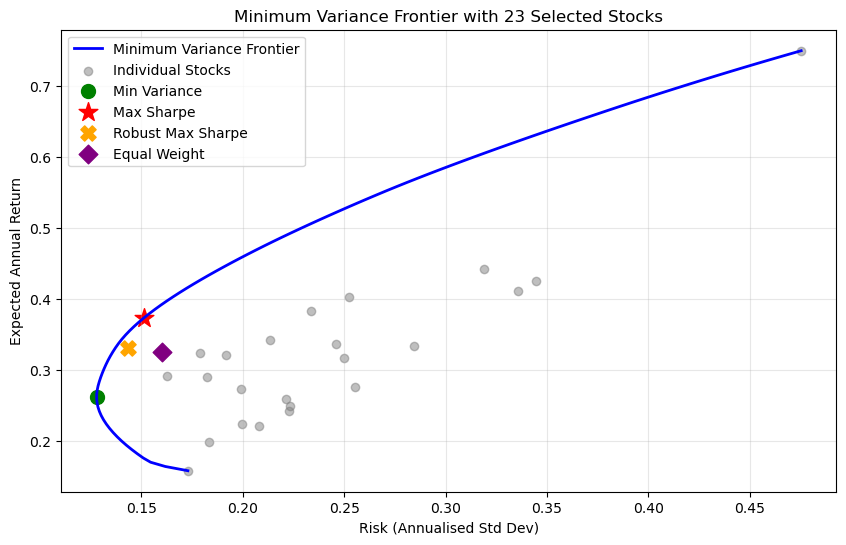

In [11]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Select final portfolio stocks
# --------------------------------------------------

PORTFOLIO_K = 23

top44_stocks = ordered_stocks[:PORTFOLIO_K]
returns44 = returns_clean[top44_stocks].dropna()

selected_stocks_with_sectors = top_stocks_with_sectors[
    top_stocks_with_sectors['Stock'].isin(top44_stocks)
].copy()

selected_stocks_with_sectors['Rank'] = selected_stocks_with_sectors['Stock'].apply(
    lambda x: top44_stocks.index(x) + 1
)

selected_stocks_with_sectors = selected_stocks_with_sectors.sort_values('Rank')

print(f"Using {PORTFOLIO_K} stocks for MVP and Max Sharpe optimisation.")
print(f"Training returns shape: {returns44.shape}")

print("\nSelected stocks and sectors:")
print(
    selected_stocks_with_sectors[
        ['Rank', 'Stock', 'Sector', 'Sharpe']
    ].to_string(index=False)
)

# --------------------------------------------------
# 2. Annualise mean returns and covariance
# --------------------------------------------------

mean_ret = returns44.mean() * 252
cov_matrix = returns44.cov() * 252
n = len(mean_ret)
risk_free = 0.02

# --------------------------------------------------
# 3. Helper functions
# --------------------------------------------------

def portfolio_risk(weights):
    return np.sqrt(weights.T @ cov_matrix @ weights)

def portfolio_stats(weights, mean_ret, cov_matrix, risk_free=0.02):
    port_ret = np.sum(weights * mean_ret)
    port_risk = np.sqrt(weights.T @ cov_matrix @ weights)
    port_sharpe = (port_ret - risk_free) / port_risk if port_risk > 0 else np.nan
    return port_ret, port_risk, port_sharpe

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

# No short selling
bounds = tuple((0, 1) for _ in range(n))

init_weights = np.array([1/n] * n)

# --------------------------------------------------
# 4. Min Variance Portfolio (MVP)
# --------------------------------------------------

result_mvp = minimize(
    portfolio_risk,
    init_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

if result_mvp.success:
    w_mvp = result_mvp.x
    ret_mvp, risk_mvp, sharpe_mvp = portfolio_stats(
        w_mvp, mean_ret, cov_matrix, risk_free
    )

    print("\nMIN VARIANCE PORTFOLIO - TRAINING DATA")
    print(f"Return: {ret_mvp:.4f} ({ret_mvp*100:.2f}%)")
    print(f"Risk:   {risk_mvp:.4f} ({risk_mvp*100:.2f}%)")
    print(f"Sharpe: {sharpe_mvp:.4f}")

    top_weights_mvp = sorted(
        zip(returns44.columns, w_mvp),
        key=lambda x: x[1],
        reverse=True
    )[:5]
    print("Top 5 holdings:", top_weights_mvp)
else:
    print("MVP optimisation failed")

# --------------------------------------------------
# 5. Max Sharpe Portfolio
# --------------------------------------------------

def neg_sharpe(weights):
    port_ret, port_risk, _ = portfolio_stats(weights, mean_ret, cov_matrix, risk_free)
    return -(port_ret - risk_free) / port_risk if port_risk > 0 else np.inf

result_sharpe = minimize(
    neg_sharpe,
    init_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

if result_sharpe.success:
    w_sharpe = result_sharpe.x
    ret_sharpe, risk_sharpe, sharpe_val = portfolio_stats(
        w_sharpe, mean_ret, cov_matrix, risk_free
    )

    print("\nMAX SHARPE PORTFOLIO - TRAINING DATA")
    print(f"Return: {ret_sharpe:.4f} ({ret_sharpe*100:.2f}%)")
    print(f"Risk:   {risk_sharpe:.4f} ({risk_sharpe*100:.2f}%)")
    print(f"Sharpe: {sharpe_val:.4f}")

    top_weights_sharpe = sorted(
        zip(returns44.columns, w_sharpe),
        key=lambda x: x[1],
        reverse=True
    )[:5]
    print("Top 5 holdings:", top_weights_sharpe)
else:
    print("Max Sharpe optimisation failed")


# --------------------------------------------------
# 6. Robust Max Sharpe Portfolio
# --------------------------------------------------
# This version reduces overfitting by shrinking expected returns toward
# their average and limiting the maximum weight in any one stock.

SHRINKAGE_ALPHA = 0.50
MAX_WEIGHT_ROBUST = 0.10

mean_ret_robust = (
    SHRINKAGE_ALPHA * mean_ret
    + (1 - SHRINKAGE_ALPHA) * mean_ret.mean()
)

robust_bounds = tuple((0, MAX_WEIGHT_ROBUST) for _ in range(n))

def neg_sharpe_robust(weights):
    port_ret = np.sum(weights * mean_ret_robust)
    port_risk = portfolio_risk(weights)
    return -(port_ret - risk_free) / port_risk if port_risk > 0 else np.inf

result_robust = minimize(
    neg_sharpe_robust,
    init_weights,
    method='SLSQP',
    bounds=robust_bounds,
    constraints=constraints
)

if result_robust.success:
    w_robust = result_robust.x
    ret_robust, risk_robust, sharpe_robust = portfolio_stats(
        w_robust, mean_ret, cov_matrix, risk_free
    )

    print("\nROBUST MAX SHARPE PORTFOLIO - TRAINING DATA")
    print(f"Return: {ret_robust:.4f} ({ret_robust*100:.2f}%)")
    print(f"Risk:   {risk_robust:.4f} ({risk_robust*100:.2f}%)")
    print(f"Sharpe: {sharpe_robust:.4f}")
    print(f"Max weight cap: {MAX_WEIGHT_ROBUST*100:.0f}%")
    print(f"Expected return shrinkage alpha: {SHRINKAGE_ALPHA:.2f}")

    top_weights_robust = sorted(
        zip(returns44.columns, w_robust),
        key=lambda x: x[1],
        reverse=True
    )[:5]
    print("Top 5 holdings:", top_weights_robust)
else:
    print("Robust Max Sharpe optimisation failed")
    w_robust = ew_weights_train.copy()
    ret_robust, risk_robust, sharpe_robust = portfolio_stats(
        w_robust, mean_ret, cov_matrix, risk_free
    )

# --------------------------------------------------
# 7. Equal-Weight Benchmark on Training Data
# --------------------------------------------------

ew_weights_train = np.array([1/n] * n)
ret_ew_train, risk_ew_train, sharpe_ew_train = portfolio_stats(
    ew_weights_train, mean_ret, cov_matrix, risk_free
)

print("\nEQUAL-WEIGHT BENCHMARK - TRAINING DATA")
print(f"Return: {ret_ew_train:.4f} ({ret_ew_train*100:.2f}%)")
print(f"Risk:   {risk_ew_train:.4f} ({risk_ew_train*100:.2f}%)")
print(f"Sharpe: {sharpe_ew_train:.4f}")

training_performance = pd.DataFrame({
    'Portfolio': ['Min Variance', 'Max Sharpe', 'Robust Max Sharpe', 'Equal Weight'],
    'Return': [ret_mvp, ret_sharpe, ret_robust, ret_ew_train],
    'Risk': [risk_mvp, risk_sharpe, risk_robust, risk_ew_train],
    'Sharpe': [sharpe_mvp, sharpe_val, sharpe_robust, sharpe_ew_train]
})

print("\nTRAINING PERFORMANCE SUMMARY")
print(training_performance.round(4).to_string(index=False))

# --------------------------------------------------
# 8. Minimum variance frontier
# --------------------------------------------------

min_ret = mean_ret.min()
max_ret = mean_ret.max()
target_returns = np.linspace(min_ret, max_ret, 100)

def min_risk_for_target(target):
    cons = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: np.sum(w * mean_ret) - target}
    ]

    res = minimize(
        portfolio_risk,
        init_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=cons
    )

    return res.fun if res.success else np.nan

frontier_risks = np.array([min_risk_for_target(t) for t in target_returns])
valid = ~np.isnan(frontier_risks)

plt.figure(figsize=(10, 6))
plt.plot(
    frontier_risks[valid],
    target_returns[valid],
    'b-',
    linewidth=2,
    label='Minimum Variance Frontier'
)

plt.scatter(
    returns44.std() * np.sqrt(252),
    mean_ret,
    c='gray',
    alpha=0.5,
    label='Individual Stocks'
)

plt.scatter(
    risk_mvp,
    ret_mvp,
    c='green',
    marker='o',
    s=100,
    label='Min Variance'
)

plt.scatter(
    risk_sharpe,
    ret_sharpe,
    c='red',
    marker='*',
    s=200,
    label='Max Sharpe'
)

plt.scatter(
    risk_robust,
    ret_robust,
    c='orange',
    marker='X',
    s=120,
    label='Robust Max Sharpe'
)

plt.scatter(
    risk_ew_train,
    ret_ew_train,
    c='purple',
    marker='D',
    s=90,
    label='Equal Weight'
)

plt.xlabel('Risk (Annualised Std Dev)')
plt.ylabel('Expected Annual Return')
plt.title('Minimum Variance Frontier with 23 Selected Stocks')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [12]:
# --------------------------------------------------
# Show full portfolio weights
# --------------------------------------------------

weights_df = pd.DataFrame({
    'Stock': returns44.columns,
    'Sector': [
        selected_stocks_with_sectors.set_index('Stock').loc[stock, 'Sector']
        for stock in returns44.columns
    ],
    'MVP_weight': w_mvp,
    'Max_Sharpe_weight': w_sharpe,
    'Robust_Max_Sharpe_weight': w_robust
})

weights_df['MVP_weight_pct'] = weights_df['MVP_weight'] * 100
weights_df['Max_Sharpe_weight_pct'] = weights_df['Max_Sharpe_weight'] * 100
weights_df['Robust_Max_Sharpe_weight_pct'] = weights_df['Robust_Max_Sharpe_weight'] * 100

weights_df = weights_df.sort_values('Max_Sharpe_weight', ascending=False)

print("\nFULL PORTFOLIO WEIGHTS")
print(
    weights_df[
        ['Stock', 'Sector', 'MVP_weight_pct', 'Max_Sharpe_weight_pct', 'Robust_Max_Sharpe_weight_pct']
    ].round(2).to_string(index=False)
)



FULL PORTFOLIO WEIGHTS
          Stock             Sector  MVP_weight_pct  Max_Sharpe_weight_pct  Robust_Max_Sharpe_weight_pct
  AZO US Equity  Consumer_Cyclical           25.51                  26.58                         10.00
   MO US Equity Consumer_Defensive           26.84                  21.50                         10.00
 REGN US Equity         Healthcare            0.00                  10.99                          4.46
  HRL US Equity Consumer_Defensive           11.16                  10.80                         10.00
  RAI US Equity            Unknown            0.71                  10.03                         10.00
 ORLY US Equity  Consumer_Cyclical            0.00                   6.42                         10.00
  EXR US Equity        Real_Estate            0.00                   5.01                          2.55
  STZ US Equity Consumer_Defensive            0.00                   3.17                          2.59
   HD US Equity  Consumer_Cyclical      

#### The optimized portfolios are concentrated in a small number of stocks. A robust Max Sharpe portfolio is added using expected-return shrinkage and a 10% weight cap to reduce overfitting.


#### Testing the Max Sharpe portfolio and Min Variance portfolio using the same stocks 

In [13]:
# --------------------------------------------------
# 1. Load test sector returns for the selected stocks
# --------------------------------------------------

test_file_list = [
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Industrials.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Technology.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Financial_Services.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Utilities.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Healthcare.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Unknown.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Energy.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Consumer_Defensive.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Real_Estate.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Basic_Materials.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Consumer_Cyclical.csv',
    '/Users/chikhay/Monash/ADS2001/Sectors_test/Communication_Services.csv'
]

TESTING_START = '2017-01-01'
TESTING_END = '2019-12-31'

def load_test_returns_for_stocks(stock_list, start_date, end_date):
    all_data = []

    for file_path in test_file_list:
        df = pd.read_csv(file_path)
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)
        df = df.loc[start_date:end_date]

        if df.empty:
            continue

        if (df.iloc[0] == 0).all():
            df = df.iloc[1:]

        common = [stock for stock in stock_list if stock in df.columns]

        if common:
            subset = df[common].replace(0, np.nan)
            all_data.append(subset)

    if not all_data:
        return pd.DataFrame()

    combined = pd.concat(all_data, axis=1)

    # Keep the exact same stock order as the training data
    combined = combined.reindex(columns=stock_list)

    # Drop dates where all selected stocks are missing
    combined = combined.dropna(how='all')

    return combined

# Get test returns for the selected 23 stocks
test_returns23 = load_test_returns_for_stocks(
    top44_stocks,
    TESTING_START,
    TESTING_END
)

# Use only rows where all selected stocks have valid returns
# Keep dates where at least 80% of selected stocks have data
min_valid_stocks = int(0.8 * len(top44_stocks))

test_returns23_clean = test_returns23.dropna(thresh=min_valid_stocks)

# Fill remaining missing values with 0
# This means if a stock has no valid return that day, we assume 0 contribution for that day.
test_returns23_clean = test_returns23_clean.fillna(0)

print(f"Minimum valid stocks required per day: {min_valid_stocks}")
print(f"Test returns shape before cleaning: {test_returns23.shape}")
print(f"Test returns shape after cleaning:  {test_returns23_clean.shape}")

print(f"Stocks found: {test_returns23.columns.tolist()}")


Minimum valid stocks required per day: 18
Test returns shape before cleaning: (647, 23)
Test returns shape after cleaning:  (647, 23)
Stocks found: ['MO US Equity', 'RAI US Equity', 'ORLY US Equity', 'EXR US Equity', 'AZO US Equity', 'NOC US Equity', 'HD US Equity', 'ROST US Equity', 'LMT US Equity', 'NI US Equity', 'STZ US Equity', 'ALK US Equity', 'CTAS US Equity', 'CMCSK US Equity', 'UNH US Equity', 'AOS US Equity', 'FISV US Equity', 'HRL US Equity', 'EVRG US Equity', 'FL US Equity', 'IT US Equity', 'REGN US Equity', 'SHW US Equity']


In [14]:
# --------------------------------------------------
# Test the trained portfolios out-of-sample
# --------------------------------------------------
# Uses:
#   w_mvp                 - weights from training Min Variance Portfolio
#   w_sharpe              - weights from training Max Sharpe Portfolio
#   w_robust              - weights from Robust Max Sharpe Portfolio
#   ew_weights_train      - equal-weight benchmark from training cell
#   test_returns23_clean  - 2017-2019 test returns for the selected 23 stocks
# --------------------------------------------------

def portfolio_performance(weights, returns_df, risk_free=0.02):
    mean_ret_test = returns_df.mean() * 252
    cov_test = returns_df.cov() * 252

    port_ret = np.sum(weights * mean_ret_test)
    port_risk = np.sqrt(weights.T @ cov_test @ weights)
    sharpe = (port_ret - risk_free) / port_risk if port_risk > 0 else np.nan

    return port_ret, port_risk, sharpe

# Compute out-of-sample performance
oos_ret_mvp, oos_risk_mvp, oos_sharpe_mvp = portfolio_performance(
    w_mvp,
    test_returns23_clean,
    risk_free
)

oos_ret_sharpe, oos_risk_sharpe, oos_sharpe_sharpe = portfolio_performance(
    w_sharpe,
    test_returns23_clean,
    risk_free
)

oos_ret_robust, oos_risk_robust, oos_sharpe_robust = portfolio_performance(
    w_robust,
    test_returns23_clean,
    risk_free
)

oos_ret_ew, oos_risk_ew, oos_sharpe_ew = portfolio_performance(
    ew_weights_train,
    test_returns23_clean,
    risk_free
)

print("=== OUT-OF-SAMPLE PERFORMANCE (2017-2019) ===")

print("\nMin Variance Portfolio:")
print(f"  Return: {oos_ret_mvp:.4f} ({oos_ret_mvp*100:.2f}%)")
print(f"  Risk:   {oos_risk_mvp:.4f} ({oos_risk_mvp*100:.2f}%)")
print(f"  Sharpe: {oos_sharpe_mvp:.4f}")

print("\nMax Sharpe Portfolio:")
print(f"  Return: {oos_ret_sharpe:.4f} ({oos_ret_sharpe*100:.2f}%)")
print(f"  Risk:   {oos_risk_sharpe:.4f} ({oos_risk_sharpe*100:.2f}%)")
print(f"  Sharpe: {oos_sharpe_sharpe:.4f}")

print("\nRobust Max Sharpe Portfolio:")
print(f"  Return: {oos_ret_robust:.4f} ({oos_ret_robust*100:.2f}%)")
print(f"  Risk:   {oos_risk_robust:.4f} ({oos_risk_robust*100:.2f}%)")
print(f"  Sharpe: {oos_sharpe_robust:.4f}")

print("\nEqual-Weight Benchmark:")
print(f"  Return: {oos_ret_ew:.4f} ({oos_ret_ew*100:.2f}%)")
print(f"  Risk:   {oos_risk_ew:.4f} ({oos_risk_ew*100:.2f}%)")
print(f"  Sharpe: {oos_sharpe_ew:.4f}")

testing_performance = pd.DataFrame({
    'Portfolio': ['Min Variance', 'Max Sharpe', 'Robust Max Sharpe', 'Equal Weight'],
    'Return': [oos_ret_mvp, oos_ret_sharpe, oos_ret_robust, oos_ret_ew],
    'Risk': [oos_risk_mvp, oos_risk_sharpe, oos_risk_robust, oos_risk_ew],
    'Sharpe': [oos_sharpe_mvp, oos_sharpe_sharpe, oos_sharpe_robust, oos_sharpe_ew]
})

print("\nTESTING PERFORMANCE SUMMARY")
print(testing_performance.round(4).to_string(index=False))

comparison_performance = training_performance.merge(
    testing_performance,
    on='Portfolio',
    suffixes=('_Training', '_Testing')
)

print("\nTRAINING VS TESTING SUMMARY")
print(comparison_performance.round(4).to_string(index=False))


=== OUT-OF-SAMPLE PERFORMANCE (2017-2019) ===

Min Variance Portfolio:
  Return: 0.0850 (8.50%)
  Risk:   0.1220 (12.20%)
  Sharpe: 0.5326

Max Sharpe Portfolio:
  Return: 0.0779 (7.79%)
  Risk:   0.1288 (12.88%)
  Sharpe: 0.4500

Robust Max Sharpe Portfolio:
  Return: 0.1323 (13.23%)
  Risk:   0.1078 (10.78%)
  Sharpe: 1.0417

Equal-Weight Benchmark:
  Return: 0.1278 (12.78%)
  Risk:   0.1057 (10.57%)
  Sharpe: 1.0192

TESTING PERFORMANCE SUMMARY
        Portfolio  Return   Risk  Sharpe
     Min Variance  0.0850 0.1220  0.5326
       Max Sharpe  0.0779 0.1288  0.4500
Robust Max Sharpe  0.1323 0.1078  1.0417
     Equal Weight  0.1278 0.1057  1.0192

TRAINING VS TESTING SUMMARY
        Portfolio  Return_Training  Risk_Training  Sharpe_Training  Return_Testing  Risk_Testing  Sharpe_Testing
     Min Variance           0.2623         0.1280           1.8934          0.0850        0.1220          0.5326
       Max Sharpe           0.3734         0.1512           2.3377          0.0779      

#### Max Sharpe is more aggressive and overfits more. Robust Max Sharpe is more careful and diversified, so it performed better on new testing data.

## Smaller portfolio size check: the notebook now trains on 2010-2016, tests on 2017-2019, and uses the best out-of-sample k for the final portfolio cells
